In [3]:
import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

We are now going to take on the Titanic dataset, and predict wheter a given passanger will survive or not - given a few features.

Make sure to read about the dataset [here.](https://www.kaggle.com/c/titanic/data)

In [4]:
# load the titanic dataset

titanic_df = pd.read_csv('../data/titanic.csv')

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


---

## Challenges

**Task 1**

Read the documentation of the dataset, and think carefully about the features available. Which ones do you think are relevant to predict wether someone survives or not?

Now drop the columns you think are redundant.

In [ ]:
# Task 1 + Task 2: choose useful features, do EDA, clean data, and prepare X/y
from IPython.display import display

# 1) Quick EDA to understand the dataset
print('Shape:', titanic_df.shape)
print('\nColumns:')
print(titanic_df.columns.tolist())
print('\nMissing values per column:')
print(titanic_df.isna().sum().sort_values(ascending=False))

display(titanic_df.head())

# 2) Drop columns that are usually not very helpful for this baseline model
drop_columns = ['PassengerId', 'Cabin', 'Ticket']
work_df = titanic_df.drop(columns=drop_columns).copy()

# 3) Feature engineering before dropping Name
work_df['FamilySize'] = work_df['SibSp'] + work_df['Parch'] + 1 #creates a new feature.
#Why: survival can depend on whether someone was traveling alone or with family.
#How: SibSp counts siblings/spouses, Parch counts parents/children, and + 1 includes the passenger themself.
work_df['IsAlone'] = (work_df['FamilySize'] == 1).astype(int)

# 4) Handle missing values
work_df['Embarked'] = work_df['Embarked'].fillna(work_df['Embarked'].mode()[0])
work_df['Age'] = work_df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda s: s.fillna(s.median()))
work_df['Age'] = work_df['Age'].fillna(work_df['Age'].median())

# 5) Drop Name after engineering (we keep model simple here)
work_df = work_df.drop(columns=['Name'])

# 6) Separate target and features
y = work_df['Survived']
X = work_df.drop(columns=['Survived'])

# 7) One-hot encode categorical features
categorical_cols = ['Sex', 'Embarked', 'Pclass']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print('\nPrepared feature matrix shape:', X.shape)
print('Prepared target vector shape:', y.shape)
print('\nPrepared features preview:')
display(X.head())

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values per column:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Prepared feature matrix shape: (891, 11)
Prepared target vector shape: (891,)

Prepared features preview:


,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,22.0,1,0,7.2500,2,0,True,False,True,False,True
1,38.0,1,0,71.2833,2,0,False,False,False,False,False
2,26.0,0,0,7.9250,1,1,False,False,True,False,True
3,35.0,1,0,53.1000,2,0,False,False,True,False,False
4,35.0,0,0,8.0500,1,1,True,False,True,False,True


**Task 2**

Do some preliminary EDA, and clean columns in a suitable way if warranted. Remember to also conduct (if needed) feature engineering, one-hot-encoding (categorical columns) etc.

In general, prepare your data for training.

*Note*: You do NOT need to do any feature scaling for logistic regression.

**Task 3**

Train a logistic regression model to predict wether someone survives, or not. 

Use 5-fold cross-validation to assess performance.

Use accuracy, precision and recall score.

In [6]:
# Task 3: train logistic regression with 5-fold cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_model = LogisticRegression(max_iter=2000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall']
cv_results = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print('5-fold CV results (mean +/- std):')
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric:>9}: {scores.mean():.4f} +/- {scores.std():.4f}")

5-fold CV results (mean +/- std):
 accuracy: 0.8081 +/- 0.0183
precision: 0.7793 +/- 0.0303
   recall: 0.6987 +/- 0.0341


**Task 4**

Now do a normal train/test split and train a logistic model on this.

Plot a confusion matrix on the predictions of your test set. Is your model performing okay-ish?

Test-set metrics:
Accuracy : 0.8101
Precision: 0.8070
Recall   : 0.6667


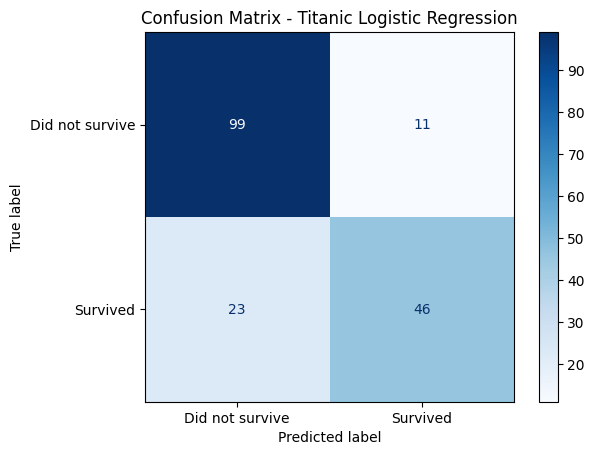

In [7]:
# Task 4: normal train/test split, evaluate, and plot confusion matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

final_model = LogisticRegression(max_iter=2000, random_state=42)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print('Test-set metrics:')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Titanic Logistic Regression')
plt.show()